# Getting started with Colab and Python

Let's make a simple plot with Python in Colab and learn a few things about Python along the way.

1. Import `pandas` library for `DataFrame` manipulation.
2. Download the `Iris` dataset from Kaggle.
3. Load dataset into a `pandas` `DataFrame`.
4. Handle exceptions with `try...except`.
5. Explore the `DataFrame`.
6. Plot data with `matplotlib`.
7. Plot data with `seaborn`.

Along the way, you're also going to pick up:

- Create text cells with markdown language.
- Create and run code cells.
- Use the terminal (aka shell).
- Understand Colab controls and settings.
- Use Gemini AI in Colab.

# 1. Import the `pandas` library

Import `pandas` for data frame manipulation.

In Colab, this library is pre-loaded. If it was not, we'd have to install it using the `pip` Python package manager.

In [2]:
!pip install pandas  # installing on the shell with pip

When you use `pip install pandas`, `pip` typically retrieves the `pandas` package from the Python Package Index (PyPI), which is the official third-party software repository for Python. It then installs the package and its dependencies into your Python environment.

**Tip**: Open [PyPi.org](https://pypi.org) in another browser tab, then search for `pandas`, and you get to the [pandas documentation](https://pypi.org/project/pandas/).

`pandas` is already there, so we can just import it:

In [3]:
import pandas as pd

To check that the library is loaded and available in the current session:


In [4]:
import sys
print('pandas' in sys.modules)

True


In this command, Python looks for the string `pandas` in the `keys` of the dictionary. If it is found (because it was loaded), then a Boolean value, `True`, is returned.

# 2. Download CSV data from Kaggle into a `DataFrame`

Kaggle ([kaggle.com](https://kaggle.com)) is a platform for data science and machine learning. It offers free datasets and free cloud-based notebooks, and hosts data science competitions (with big prizes).

We download the classic `Iris` dataset from Kaggle. You can download it directly from this URL: `https://tinyurl.com/iris-data-csv`:


In [5]:
data_url = 'https://tinyurl.com/iris-data-csv' # save URL in variable

Load the dataset into a `pandas` `DataFrame`:

In [6]:
pd.read_csv(data_url) # fetches the web data and displays them

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


This is not safe though - what if the dataset does not exist in this location? When interacting with the web, you always want to handle exceptions:

In [7]:
try:
  df = pd.read_csv(data_url)
  print("Dataset downloaded and loaded successfully!")
except Exception as e:
  print(f"Error loading dataset: {e}")
  print("Please check your internet connection or the URL")

Dataset downloaded and loaded successfully!


The statement `print(f"Error...{e}")` contains an f-string that allows you to print variables (here the value in the exception `e`) inside strings.

`Exception` is a class of several different exceptions, errors and warnings that can occur ([see here](https://docs.python.org/3/library/exceptions.html)).

# 3. Explore the data

This is where the fun begins: You now get to look at the data with the eye of a detective.

We already saw what happened when we try to print the entire `DataFrame`:

In [8]:
print(df)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


We are protected against overflow. You can also specify if you want to look at the top or bottom N rows only:

In [9]:
print(df.head(3))
print(df.tail(3))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


Notice how the function `head()` is applied to the `DataFrame`: The dot operator  `.` binds the method `pandas.head()` to the `pandas` object `df`.

There is a safer way to do this that checks if the `DataFrame` is actually loaded and available as a local variable in `locals()`:

In [11]:
if 'df' in locals():
  print(df.head())
else:
  print("DataFrame 'df' not found. Run previous cell to load it?")

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


The error message suggests a common issue in notebooks: When you come back to it after a while, your instance will have been disconnected, and your session has ended. You now must run all cells up to this point to repopulate the session, using the `Runtime -> Run all` tab at the top.

Another useful function is `pandas.DataFrame.info()`. As you can guess from the name, this is a function in the `DataFrame` module of the `pandas` library. However, you simply call it on an existing `DataFrame`:

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


If you want to know more about `pandas`, try the [tutorial in the textbook](https://colab.research.google.com/github/ageron/handson-mlp/blob/main/tools_pandas.ipynb).

Lastly, let's get a glimpse of the statistical properties of the data:

In [18]:
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


# 4. Plotting with Python

Making plots or graphs is another way of exploring the data. Two popular graphics packages in Python are `matplotlib` and `seaborn`.

`matplotlib` is a low-level plotting library that can draw figures, axes, labels, lines, etc.

We only need to `import` a sub-library or module of `matplotlib`, `pyplot`, with the alias `plt`.

As an exercise, `import` that module now, and then check if it was loaded or not.

In [16]:
import matplotlib.pyplot as plt
print('matplotlib.pyplot' in sys.modules)

True


A common source of error: The alias `plt` is not loaded but it's the name that you need to use to access methods.

Aliases like `plt` are local variable bindings in your namespace - they do not appear in `sys.modules`. When you do `import matplotlib.pyplot as plt`, Python:
1. Loads the module `matplotlib.pyplot` if not already loaded.
2. Stores it in `sys.modules` under its true name.
3. Binds a reference to that module object to the name `plt` in your current namespace

# 5. Decide what you want to plot

So far we haven't cared at all what these data are and what they mean. If you don't want to do a web search, this is a perfect entry for AI.

Open the Gemini console, and ask:
```
What is in the `Iris` dataset, and where does it come from?
```

*Once you got the answer, you can ask Gemini to add it to the notebook. If it does not give you a link to look up more, ask for it. If it gives you a Wikipedia link, ask for another. The best source is the UCI archive (see below).:

"The `Iris` dataset is a classic and widely used dataset in machine learning and statistics. It contains 150 samples of iris flowers, with each sample having four features: sepal length, sepal width, petal length, and petal width, all measured in centimeters. Each sample is also labeled with one of three species of iris: Setosa, Versicolor, or Virginica. It's often used for classification tasks to predict the species of an iris flower based on its measurements. The dataset was introduced by the British statistician and biologist Ronald Fisher in 1936.

For a comprehensive reference, you can find the Iris dataset at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/iris)."

Now you know! Now the columns of the `DataFrame` make sense. Print the `info()` again:

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


**Question:** What additional information does this table give us?

**Answer:**
1. There are for numeric (0-3) and one categorical feature (`species`).
2. The numeric features are represented as floating-point numbers.
3. There are no missing values (`NaN`).

Without this semantic detour, plotting makes no sense because you have to identify what you want to plot and why, before you decide how. And the plotting functions require decisions on coordinates and other customizations from you.

**Question:** What can we plot and how?

**Answer:**
1. We can create *scatterplots* of the numeric variables (in 2D or in 3D) for all `species` to see how they vary by `species`.
2. We can create *barplots* of the mean value of each feature per `species` to compare average measurements across groups.
3. We can create *boxplots* for each feature against the `species` to show the statistical properties of the distributions.

In this notebook, we will only demonstrate scatterplots. For a collection of hundreds of charts made with Python using different graphics packages, see [The Python Graph Gallery](https://python-graph-gallery.com/).

# 6. Create a simple plot with `matplotlib`

First, we create a simple plot that shows the relationship of two features for all `species`, `sepal_length` and `sepal_width`.

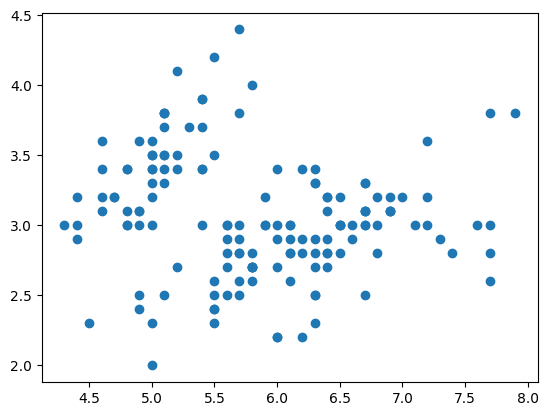

In [38]:
plt.scatter(x=df['sepal_length'],
            y=df['sepal_width'])
plt.show()

To access the features, which are stored as vectors in the columns of the DataFrame, we used the subscript or index operator [] and the names of the features. The plotting function then picks the values from the column one after the next in order of appearance/sampling.

This plot is easier to understand with some minimal customization, like a title, and labels for x and y coordinates.

Unlike other commands, we cannot just add these to an existing plot but we must clean the graphics and create a new plot. But in Colab, you can copy the previous code block and add to it:

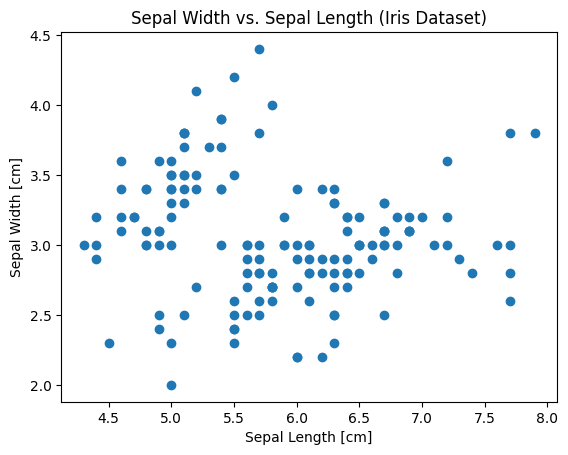

In [39]:
plt.clf()
plt.scatter(x=df['sepal_length'],
            y=df['sepal_width'])
plt.title("Sepal Width vs. Sepal Length (Iris Dataset)")
plt.xlabel("Sepal Length [cm]")
plt.ylabel("Sepal Width [cm]")
plt.show()

There is no grouping here, no colors by species, just a straight plot of all the data in two columns.

In this way we're losing information that is actually there.

The `Iris` dataset is often used to demonstrate the abilities of machine learning models to cluster the three species - group them based on having learnt labeled data.

To show this here, we subset (group) the data by `species` and then plot the groups in a loop:

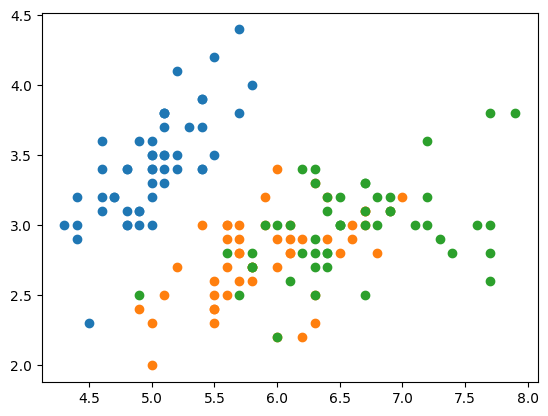

In [40]:
plt.clf()
for s in df['species'].unique(): # iterate over the 3 unique species names
  sub = df[df['species']==s]     # filter df to rows where species match s
  plt.scatter(x=sub['sepal_length'], # x-axis: sepal length for species s
              y=sub['sepal_width'],  # y-axis: sepal_width for species s
              label=s)
plt.show()

Let's see how this works:
1. `df['species'].unique()` returns a list of the three unique species names

In [41]:
print(df['species'].unique())

['setosa' 'versicolor' 'virginica']


   2. `df['species'==s]` produces a series of Booleans (`True` for the currently processed value of `species`, `False` otherwise).

In [42]:
s = 'setosa'
print(df['species']==s)

0       True
1       True
2       True
3       True
4       True
       ...  
145    False
146    False
147    False
148    False
149    False
Name: species, Length: 150, dtype: bool


   3. `df[...]` uses that Boolean series as a filter and keeps only rows where the value is `True` - a total of 50 rows x 5 columns for each `species`.

In [43]:
sub = df[df['species']==s]
print(sub.shape)

(50, 5)


   4. `plt.scatter(x=sub[...],y=sub[...])` then plots each group. The `label` parameter assigns a different color to each group automatically.

The grouping by masking row values using a Boolean index vector is worth showing in another example because it's a common trick:

In [44]:
s = 'setosa'
mask = df['species']==s  # Step 1: Boolean series
sub = df[mask]           # Step 2: Filter rows using mask
print(mask.head())       # Show True/False values
print(sub.head())        # Show the filtered rows

0    True
1    True
2    True
3    True
4    True
Name: species, dtype: bool
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


For more information on `matplotlib`, see [Geron's tutorial](https://colab.research.google.com/github/ageron/handson-ml3/blob/main/tools_matplotlib.ipynb).

As a small challenge, copy the previous plot and add a title and axis labels as before.

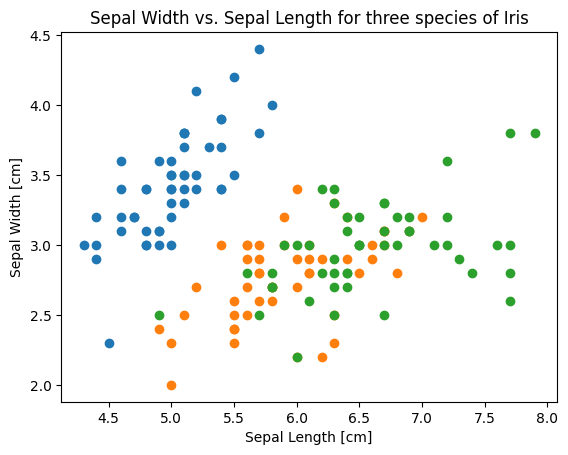

In [45]:
plt.clf()
plt.title("Sepal Width vs. Sepal Length for three species of Iris")
plt.xlabel("Sepal Length [cm]")
plt.ylabel("Sepal Width [cm]")
for s in df['species'].unique():
    sub = df[df['species']==s]
    plt.scatter(x=sub['sepal_length'],
                y=sub['sepal_width'],
                label=s)
plt.show()

Were you trying to put the title and label definitions inside the loop right after the `plt.scatter()` call? This would work, too, but it would print them on top of one another three times.

In Python, the preparation of the figure and the plotting of the data, are interleaved. You will see that even more clearly with the next graphics package, `seaborn`.

# 7. Create a fancy plot with `seaborn`



The `seaborn` library is built on top of `matplotlib` and allows automatic grouping of the data by the variable `species`.

First, we load the library, and check if the loading worked by asking if the alias is available in the current namespace.

In [34]:
import seaborn as sns
print('sns' in locals())

True


Now we create a fancy plot with grouping by `species` in one line of code:

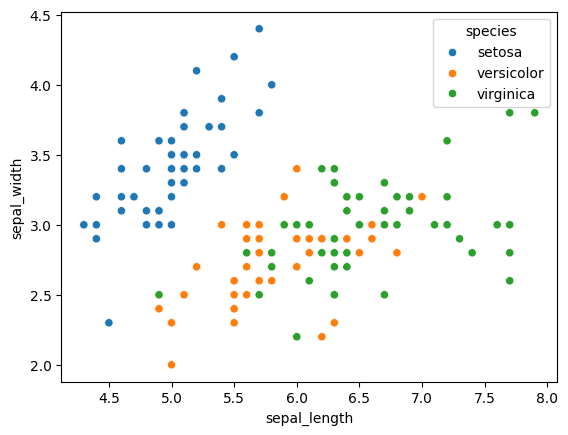

In [37]:
plt.clf()
sns.scatterplot(data = df,
                x = 'sepal_length',
                y = 'sepal_width',
                hue = 'species')     # display species with different color
plt.show()

The customization is done using `matplotlib` functions. We copy the previous code and add title, labels, and, for greater readability, a grid.

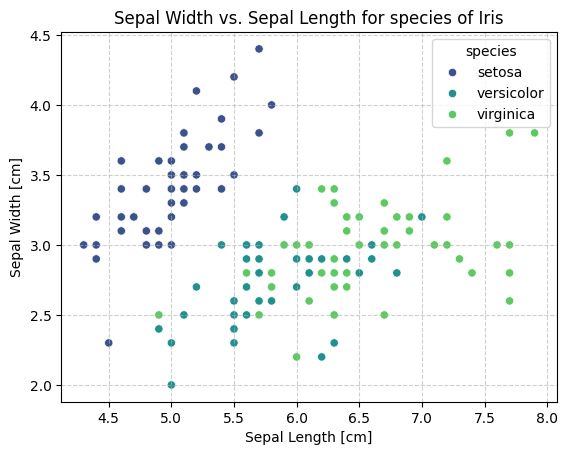

In [52]:
# base plot
plt.clf()
sns.scatterplot(data = df,
                x = 'sepal_length',
                y = 'sepal_width',
                hue = 'species',
                palette = 'viridis')
# customization
plt.title("Sepal Width vs. Sepal Length for species of Iris")
plt.xlabel("Sepal Length [cm]")
plt.ylabel("Sepal Width [cm]")
plt.grid(True, # show a grid
        linestyle = '--', # set the line style
        alpha = 0.6) # set the grid line transparency
plt.show()

# 8. Home assignment

Test your understanding of "Getting started with Colab (and Python)" by creating a notebook for the Palmer Penguin dataset available for you online from: `tinyurl.com/palmer-data-csv`.

Tasks:

1. Create a new Colab notebook.
2. Load `pandas` with the alias `pd`.
3. Load the dataset into a `DataFrame` `df` with `pd.read_csv`
4. Check if the dataset is loaded in the current namespace by checking if `pd` is in `locals()`.
5. Display the first few lines of the dataset with `pd.head()`, and the structure of the `DataFrame` with `info()`.
6. Make a simple plot of the `bill_length_mm` as a function of `bill_depth_mm` features using `matplotlib.pyplot` as `plt`.
7. Make a fully customized plot of the dataset grouping by species using `seaborn` as `sns`.
8. Make sure that the notebook is shared.
9. Upload the (shareable) URL to your finished notebook to Teams.
10. **Use markdown for headlines and comments (outside of the code blocks), and created a structured notebook, not just a bunch of code!**
11. Ask Gemini for a critique of your solution and add its critique at the end of the notebook.


Let me know if you have any problems!